"""
generate queries
- query 1
- query 2

web researcher
 - tool search
 - summarize each page


https://github.com/triggerdotdev/examples/blob/main/vercel-ai-sdk-deep-research-agent/src/trigger/deepResearch.ts#L317
https://aie-feb-25.vercel.app/docs/deep-research

"""

In [1]:
# Core imports shared by all examples
from __future__ import annotations

from typing import Any, List

from IPython.display import Image, display
from langgraph.graph import StateGraph, END , START
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from openinference.instrumentation.langchain import LangChainInstrumentor
from typing_extensions import Optional, Annotated, List, Sequence

from opentelemetry import trace

import rich
from langgraph.graph.message import add_messages

import operator
from langchain_core.tools import tool, InjectedToolArg
import requests
import rich

from langchain_core.messages.ai import AIMessage

In [2]:
import dotenv
import os

In [3]:
dotenv.load_dotenv("../env_workshop")

True

In [4]:
OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL")


In [5]:
PHOENIX_PROJECT_NAME=os.environ.get("PHOENIX_PROJECT_NAME")

In [6]:
from phoenix.otel import register
from openinference.instrumentation import using_metadata

# configure the Phoenix tracer
tracer_provider = register(
  project_name=PHOENIX_PROJECT_NAME, 
  auto_instrument=False 
)
LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

tracer = trace.get_tracer(__name__)


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [7]:
class WebSource(BaseModel):
    title: str
    url: str
    summary: str = None
    raw_content: str = None
    
class WebSearchResultFinding(BaseModel):
    query:str
    finding: str

class OverallState(BaseModel):
    messages: Annotated[list, add_messages] = Field(
        default_factory=list
    )


    research_brief: str = Field(default="")

    web_research_result: Annotated[list[WebSearchResultFinding], operator.add] = Field(
        default_factory=list
    )
    sources_gathered: Annotated[list[WebSource], operator.add] = Field(
        default_factory=list
    )

    initial_search_query_count: int = Field(default=0)
    
    max_research_loops: int = Field(default=3)
    research_loop_count: int = Field(default=0)
    pending_queries: list[str] = Field(default_factory=list)
    processed_queries: Annotated[list[str], operator.add] = Field(
        default_factory=list
    )


    final_report:str = Field(default="")

    last_reflection: ReflectionState = None

class ReflectionState(BaseModel):
    is_sufficient: bool
    knowledge_gap: str
    follow_up_queries: Annotated[list[str], operator.add]



class WorkerNodeState(BaseModel):
    query:str = ""
    results: list[WebSource] = Field(default_factory=list)
    finding: str = ""


class SuggestionQuery(BaseModel):
    query:str
    rationale:str 

class SuggestedQueriesResponse(BaseModel):
    queries: list[SuggestionQuery]

class QueryGenerationState(BaseModel):
    queries: list[SuggestionQuery]
    iteration:int = 0

## Tool Usages

In [8]:
TAVILY_BASE_URL = os.environ.get("TAVILY_BASE_URL")
TAVILY_BASE_URL
def tavily_search_helper(query, **kw):
    r = requests.post(TAVILY_BASE_URL,
                      json={"query": query, **kw}, timeout=60)
    r.raise_for_status()
    return r.json()

res = tavily_search_helper("what is the weather in seattle")
print(res)

{'query': 'what is the weather in seattle', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'Weather in Seattle', 'url': 'https://www.weatherapi.com/', 'content': "{'location': {'name': 'Seattle', 'region': 'Washington', 'country': 'United States of America', 'lat': 47.6064, 'lon': -122.3308, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1761677777, 'localtime': '2025-10-28 11:56'}, 'current': {'last_updated_epoch': 1761677100, 'last_updated': '2025-10-28 11:45', 'temp_c': 9.4, 'temp_f': 48.9, 'is_day': 1, 'condition': {'text': 'Overcast', 'icon': '//cdn.weatherapi.com/weather/64x64/day/122.png', 'code': 1009}, 'wind_mph': 2.2, 'wind_kph': 3.6, 'wind_degree': 153, 'wind_dir': 'SSE', 'pressure_mb': 1023.0, 'pressure_in': 30.21, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 77, 'cloud': 100, 'feelslike_c': 9.6, 'feelslike_f': 49.2, 'windchill_c': 10.2, 'windchill_f': 50.4, 'heatindex_c': 10.6, 'heatindex_f': 51.1, 'dewpoint_c': 5.0, 'dewpoint_f': 4

In [72]:
@tool(parse_docstring=True)
def web_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
) -> list[WebSource]:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query

    #print("Performing web search for query:", query)
    search_results = tavily_search_helper(
        query,
        max_results=max_results,
        include_raw_content=True,
    )



    sources = []
    for result in search_results['results']:
        content = result.get("raw_content", "")
        #summary = summarize_document(content)
        
        if not content or content.isspace():
            continue
        source = WebSource(
            title=result.get("title", ""),
            url=result.get("url", ""),
            #summary=summary,
            raw_content=content,
        )
        sources.append(source)
    return sources




@tool(parse_docstring=True)
def summarize_document(content: str) -> str:
    """Summarize the given document content using an LLM.

    Args:
        content: The raw text content of the document to summarize.

    Returns:
        A concise summary of the document.
    """
    llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0,
        openai_api_base=OPENAI_BASE_URL,
    )

    prompt = f"""
    You are an expert summarization assistant. 
    You will be given the raw text content of a web site.

    Your task is to generate a summary of the following document content.
    
    Your summary should be significantly shorter than the original content but comprehensive enough to stand alone as a source of information. Aim for about 25-30 percent of the original length, unless the content is already concise.

    Focus on capturing the key points and main ideas, while omitting extraneous details.

    Document Content:
    {content}
    """

    response :AIMessage = llm.invoke(prompt)
    return response.content


@tool(parse_docstring=True)
def generate_finding(query: str, sources: list[WebSource]) -> str:
    """Generate a finding given the search query and web sources.

    The prompt will include each source's Title, Summary, and URL to help the LLM synthesize.

    Args:
        query: The search query to generate findings for.
        sources: A list of web sources to extract information from.

    Returns:
        A synthesized finding/summary based on the sources.
    """
    llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0,
        openai_api_base=OPENAI_BASE_URL,
    )

    def _fmt_source(idx: int, src: WebSource) -> str:
        title = (src.title or "").strip() or "(untitled)"
        summary = (src.summary or "").strip() or "(no summary provided)"
        url = (src.url or "").strip()
        lines = [
            f"===== START SOURCE {idx} =====",
            f"Title: {title}",
            f"Summary:\n{summary}",
        ]
        if url:
            lines.append(f"URL: {url}")
        lines.append(f"===== END SOURCE {idx} =====")
        return "\n".join(lines)

    if sources:
        sources_block = "\n\n".join(_fmt_source(i + 1, s) for i, s in enumerate(sources))
    else:
        sources_block = "(no sources provided)"

    prompt = f"""
    You are an expert research synthesis assistant.

    Search Query:
    {query}

    Web Sources (each delimited by START/END lines, numbered for citation):
    {sources_block}

    Task:
    - Synthesize a comprehensive finding based on the query and the sources above.
    - Prefer information corroborated by multiple sources; avoid verbatim copying.
    - If sources conflict, briefly explain which seems more credible and why.
    - Keep the answer concise but complete (6–10 bullet points or 2–4 short paragraphs).
    - When citing specific claims, reference the source number in square brackets like [1], [2], etc.
    """

    response = llm.invoke(prompt)
    return response



def web_search_node(state: WorkerNodeState) -> WorkerNodeState:
    query = state.query
    results:list[WebSource] = web_search.invoke({'query': query})

    return {'results': results}

def summarize_all_doc_node(state: WorkerNodeState) -> WorkerNodeState:
    query = state.query

    for doc in state.results:
        doc.summary = summarize_document.invoke({'content': doc.raw_content})

    return {'results': state.results}


def generate_finding_node(state: WorkerNodeState) -> WorkerNodeState:
    query = state.query
    results = state.results

    response:AIMessage  = generate_finding.invoke({'query': query, 'sources': results})

    finding:str = response.content

    return {'finding': finding}

# def researcher_node(state: OverallState) -> OverallState:
#     llm = ChatOpenAI(
#         model_name="gpt-4o-mini",
#         temperature=0,
#         openai_api_base=OPENAI_BASE_URL,
        
#     )

#     tool_model = llm.bind_tools([web_search]).with_structured_output(ReflectionState)  # for tool calling

#     tool_model.invoke(state)

#     prompt = f"""
#     You are an expert research assistant. 

#     You have the following tools:

#     Tools:
#     - web_search: A tool to perform web searches to gather information on specific queries.

#     Given a user query, perform a web search using the `web_search` tool to gather relevant information.
    
#     Query: {state.search_query}


In [73]:
query = 'best running shoes 2023 expert reviews'
state = WorkerNodeState(query=query, results=[],finding='')

res_web = web_search.invoke(state.query)
state.results = res_web

state.results = summarize_all_doc_node( state)['results']
state.finding = generate_finding_node( state)['finding']


In [74]:
rich.print (state)

WorkerNodeState(
    query='best running shoes 2023 expert reviews',
    results=[
        WebSource(
            title="Runner's World's favourite running shoes from 2023",
            url='https://www.runnersworld.com/uk/gear/shoes/a46163987/running-shoe-picks-2023/',
            summary="The article presents a curated list of the best running shoes of 2023, as selected by 
experienced fitness editors after testing over 100 pairs. It highlights the advancements in running shoe 
technology, emphasizing lighter, more comfortable, and faster options that enhance performance and recovery.\n\nKey
recommendations include:\n\n1. **On Cloudsurfer** - Noted for its plush cushioning and responsive ride, ideal for 
various paces.\n2. **Saucony Triumph 21** - A top choice for long runs, offering excellent cushioning and 
stability.\n3. **Asics Gel Trabuco 11** - A versatile trail shoe that performs well on both pavement and rough 
terrain.\n4. **On Cloudstratus 3** - Praised for its balance of comfort and energy return, suitable for various 
running paces.\n5. **Nike Alphafly 3** - A pre-release model that promises stability and lightness, ideal for 
interval training.\n6. **Nike Dragonfly ZoomX** - A lightweight track shoe with excellent propulsion, suitable for 
competitive runners.\n7. **Adidas Terrex Speed Ultra** - A reliable trail shoe that combines comfort and 
performance for off-road runs.\n\nThe article also features additional recommendations from various editors, 
showcasing a range of shoes for different running styles and preferences, ensuring there's something for every 
runner.",
            raw_content='[Skip to Content](#main-content)\n\nWe earn a commission for products purchased through 
some links in this article.\n\n1. [Gear](/uk/gear/)\n2. [Running Shoes](/uk/gear/shoes/)\n3. [As a group of 
experienced fitness editors, these are our favourite running shoes from 
2023](/uk/gear/shoes/a46163987/running-shoe-picks-2023/)\n\n# As a group of experienced fitness editors, these are 
our favourite running shoes from 2023\n\nWe\'ve tested over 100 pairs this year, but these shoes made podium 
position\n\nBy [Ali Ball](/uk/author/264998/ali-ball/ "Ali Ball")\n\nTested by [The Runner\'s World 
Editors](/uk/author/214197/the-runners-world-editors-0/)\n\nThere\'s no doubt that we\'ve entered the golden age of
running shoes. Footwear is lighter, more comfortable and faster than ever before, leading to quicker recovery from 
hard workouts, more joy on easy runs and PBs on race days.\n\nAs a gear editor – who quite literally tests running 
kit for a living – one of the questions I always get asked is, \'What running shoes would you recommend?\'\n\nFor 
starters, I\'d check out our comprehensive guide to the [best running 
shoes](https://www.runnersworld.com/uk/gear/shoes/a776671/best-running-shoes/) on the market right now, which 
answers all your FAQs about how to choose the right pair for your feet, along with all of the top picks from our 
latest round of wear-testing for autumn/winter 2023. That includes shoes for 
[beginners](https://www.runnersworld.com/uk/gear/shoes/a32170097/beginner-running-shoes/), 
[overpronators](https://www.runnersworld.com/uk/gear/shoes/a42551518/overpronation-running-shoes/) and [race 
day](https://www.runnersworld.com/uk/gear/shoes/g39512517/carbon-plate-running-shoes/).\n\n## What everyone\'s 
reading\n\nBut, since it\'s Christmas – and Christmas is a time for giving – I\'ve also asked the *RW* editors to 
pick their top three favourite pairs from the past year, out of more than 100 pairs we\'ve tested. Think of it like
our desert island picks from 2023. Merry Christmas!\n\n## Andy Dixon, Editor-in-Chief\n\n## On Cloudsurfer\n\n## On
Cloudsurfer\n\n[£150 at 
On](https://go.redirectingat.com?id=127X583555&url=https%3A%2F%2Fwww.on-running.com%2Fen-gb%2Fproducts%2Fcloudsurfe
r-3md1042%2Fmens)\n\nPutting on the 
[Cloudsurfer](https://www.runnersworld.com/uk/gear/shoes/a43372414/on-cloudsurfer-7-revi

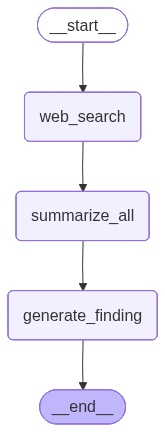

In [75]:
# Create our Agent Graph
builder_worker = StateGraph(WorkerNodeState)

# Define the nodes we will cycle between
builder_worker.add_node("web_search", web_search_node)
builder_worker.add_node("summarize_all", summarize_all_doc_node)
builder_worker.add_node("generate_finding", generate_finding_node)



builder_worker.add_edge(START, "web_search")

builder_worker.add_edge("web_search", "summarize_all")
builder_worker.add_edge("summarize_all", "generate_finding")



worker_agent = builder_worker.compile() 


worker_agent


In [76]:
query = 'best running shoes 2023 expert reviews'


initial_worker_state = WorkerNodeState(
   query=query,
)
#res = worker_agent.invoke({'query': query})

res = worker_agent.invoke(initial_worker_state)
res_worker_state:WorkerNodeState = WorkerNodeState(**res)


# state = WorkerNodeState(query=query, results=[],finding='')

# res_web = web_search.invoke(state.query)
# state.results = res_web

# state.results = summarize_all_doc_node( state)['results']
# state.finding = generate_finding_node( state)['finding']


In [14]:
type(res), type(res_worker_state)

(dict, __main__.WorkerNodeState)

In [15]:
print(isinstance(res, WorkerNodeState))


False


In [16]:
res

{'query': 'best running shoes 2023 expert reviews',
 'results': [WebSource(title="Runner's World's favourite running shoes from 2023", url='https://www.runnersworld.com/uk/gear/shoes/a46163987/running-shoe-picks-2023/', summary="The article presents a curated list of the best running shoes of 2023, as selected by experienced fitness editors after testing over 100 pairs. It highlights the advancements in running shoe technology, emphasizing lighter, more comfortable, and faster options that enhance performance and recovery.\n\nKey recommendations include:\n\n1. **On Cloudsurfer** - Noted for its plush cushioning and responsive ride, ideal for various paces.\n2. **Saucony Triumph 21** - A top choice for long runs, offering excellent cushioning and stability.\n3. **Asics Gel Trabuco 11** - A versatile trail shoe that performs well on both pavement and rough terrain.\n4. **On Cloudstratus 3** - Praised for its balance of comfort and energy return, suitable for various running paces.\n5. **

## Parent Node

In [77]:
from typing import Literal


research_brief_shoes = 'I want to know what the best running shoes are currently available, based on expert reviews and user feedback. I have not specified any particular type of running (such as road, trail, long distance, or sprinting), nor have I indicated any preferences regarding foot shape, fit, or budget. Please consider all major brands and models, and evaluate them across key dimensions such as comfort, durability, performance, and value. Since I have not specified any constraints, include options across all price ranges and for various running types. Prioritize information from official brand websites, reputable review platforms, and major e-commerce sites with substantial user feedback.'
 



def research_brief_node(state: OverallState) -> OverallState:
    return {'research_brief': research_brief_shoes}


def generate_query_node(state: OverallState) -> OverallState:
    llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0,
        openai_api_base=OPENAI_BASE_URL,
    )

    prompt = f"""
    You are an expert research assistant. 
    
    Your task is to generate upto `5` search queries to help find information based on the research brief provided.
    
    The queries should address different aspects of the research brief to ensure comprehensive coverage of the topic.
    Don't repeat yourself.

    Each query should be accompanied by a brief rationale explaining why it is important for the research.
    Provide a list of search queries along with their rationales.
    
    
    Research Brief: {state.research_brief}"""


    model_with_structured_output = llm.with_structured_output(SuggestedQueriesResponse)



    res:SuggestedQueriesResponse = model_with_structured_output.invoke(prompt)


    return {"pending_queries": [q.query for q in res.queries] }



def web_research_node(state:OverallState) -> OverallState:
    all_findings = []
    all_sources = []


    inputs = [WorkerNodeState(query=query, results=[], finding='') for query in state.pending_queries]
    raw_outs: List[dict] = worker_agent.map().invoke(inputs)
    outs: List[WorkerNodeState] = [WorkerNodeState(**out) for out in raw_outs]


    pending_queries_str = "\n".join(f"- {item}" for item in state.pending_queries)
    
    if state.research_loop_count ==0:
        print("Research Brief:")
        print(state.research_brief)
    
    print(f"""
    Iteration {state.research_loop_count}
    Search Queries: 
    {pending_queries_str}
    """)
    
    for out in outs:
        all_findings.append(
            WebSearchResultFinding(
                query=out.query,
                finding=out.finding
            )
        )
        all_sources.extend(out.results)


    return {
        'web_research_result': all_findings,
        'pending_queries': [],
        'processed_queries':  state.pending_queries,
        'sources_gathered': all_sources,
        'research_loop_count': state.research_loop_count + 1
    }


def reflection_node(state: OverallState) -> OverallState:
    llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0,
        openai_api_base=OPENAI_BASE_URL,
    )

    prompt = f"""
    You are an expert research assistant. 

    Based on the research brief and the findings from web research, determine if the information gathered is sufficient to answer the research brief comprehensively.

    If there are gaps in the information, identify them and suggest follow-up search queries to address these gaps.
    The follow-up queries should be very specific and targeted to fill the identified knowledge gaps.
    The follow-up queries should be phrased as search queries suitable for a web search tool.

    Research Brief: {state.research_brief}

    Web Research Findings:
    {state.web_research_result}
    """

    model_with_structured_output = llm.with_structured_output(ReflectionState)

    res:ReflectionState = model_with_structured_output.invoke(prompt)

    print (res)



    return {'last_reflection': res, "pending_queries": res.follow_up_queries}


def synthesize_node(state: OverallState) -> OverallState:
    llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0,
        openai_api_base=OPENAI_BASE_URL,
    )

    prompt = f"""
    You are an expert research synthesis assistant.

    Using the research brief, web research findings, synthesize a comprehensive answer to the research brief.

    Return the report as markdown.

    Research Brief: {state.research_brief}

    Web Research Findings:
    {state.web_research_result}


    """

    response:AIMessage = llm.invoke(prompt)


    return {"final_report": response.content}




def evaluate_research_node(
    state: OverallState
) -> Literal["web_research", "synthesize"]:
    """LangGraph routing function that determines the next step in the research flow.

    Controls the research loop by deciding whether to continue gathering information
    or to finalize the summary based on the configured maximum number of research loops.

    Args:
        state: Current graph state containing the research loop count
        config: Configuration for the runnable, including max_research_loops setting

    Returns:
        String literal indicating the next node to visit ("web_research" or "finalize_summary")
    """

    if state.research_loop_count > state.max_research_loops or state.last_reflection.is_sufficient:
        return "synthesize"

    else:
        return "web_research"
        



In [78]:

# # Create our Agent Graph
# builder = StateGraph(OverallState)

# # Define the nodes we will cycle between
# builder.add_node("generate_query", generate_query_node)
# builder.add_edge(START, "generate_query")
# agent = builder.compile()
# agent
# initial_state = OverallState(
#     messages=[],
#     search_query=[],
#     research_brief=research_brief_shoes,        
#     web_research_result=[],
#     sources_gathered=[],
#     initial_search_query_count=0,
#     max_research_loops=3,
#     research_loop_count=0,
#     queries = []
# )
# agent.invoke(initial_state)

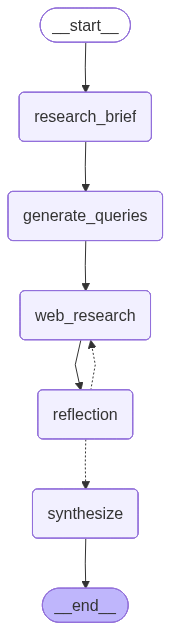

In [79]:
# Create our Agent Graph
builder_parent = StateGraph(OverallState)

builder_parent.add_node("research_brief", research_brief_node)
builder_parent.add_node("generate_queries", generate_query_node)
builder_parent.add_node("web_research", web_research_node)
builder_parent.add_node("reflection", reflection_node)
builder_parent.add_node("synthesize", synthesize_node)


builder_parent.add_edge(START, "research_brief")
builder_parent.add_edge("research_brief", "generate_queries")
builder_parent.add_edge("generate_queries", "web_research")
builder_parent.add_edge("web_research", "reflection")
builder_parent.add_conditional_edges(
    "reflection", evaluate_research_node, ["web_research", "synthesize"]
)
builder_parent.add_edge("synthesize", END)

parent_agent = builder_parent.compile()

parent_agent


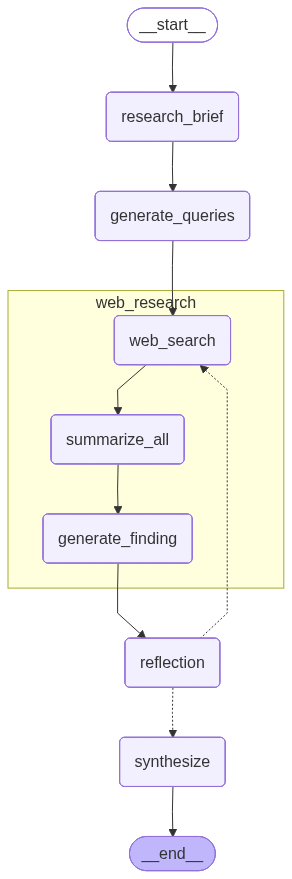

In [80]:
from IPython.display import Image, display
display(Image(parent_agent.get_graph(xray=True).draw_mermaid_png()))

In [81]:
initial_state = OverallState(
    messages=[],
    max_research_loops=10,
   
)
res_parent = parent_agent.invoke(initial_state, {"recursion_limit": 50} )
res_parent = OverallState(**res_parent)

Research Brief:
I want to know what the best running shoes are currently available, based on expert reviews and user feedback. I have not specified any particular type of running (such as road, trail, long distance, or sprinting), nor have I indicated any preferences regarding foot shape, fit, or budget. Please consider all major brands and models, and evaluate them across key dimensions such as comfort, durability, performance, and value. Since I have not specified any constraints, include options across all price ranges and for various running types. Prioritize information from official brand websites, reputable review platforms, and major e-commerce sites with substantial user feedback.

    Iteration 0
    Search Queries: 
    - best running shoes 2023 expert reviews
- top running shoes user feedback 2023
- running shoes comparison comfort durability performance value
- best running shoes for different types of running 2023
- running shoes reviews by brand 2023
    
is_sufficient=F

In [47]:
len(res_parent.processed_queries)

57

In [46]:
res_parent.processed_queries

['best running shoes 2023 expert reviews',
 'top running shoes user feedback 2023',
 'running shoes comparison comfort durability performance value',
 'best running shoes for different types of running 2023',
 'running shoes reviews by brand 2023',
 'detailed comparison of comfort durability performance value for running shoes 2023',
 'user feedback on running shoes for different foot shapes and fits 2023',
 'latest technological advancements in running shoes 2023',
 'best budget running shoes for different types of running 2023',
 'comprehensive reviews of running shoes by brand focusing on comfort and performance 2023',
 'best running shoes for narrow feet 2023',
 'best running shoes for wide feet 2023',
 'detailed comparison of running shoes under $100 2023',
 'latest technological advancements in running shoes 2023',
 'best running shoes for overpronation 2023',
 'user reviews on running shoes for different terrains 2023',
 'best budget running shoes for trail running 2023',
 'top 

In [44]:
res_parent.last_reflection

ReflectionState(is_sufficient=True, knowledge_gap='', follow_up_queries=[])

In [45]:
worker_agent.invoke({'query': 'running shoes comparison comfort durability performance value'})


Performing web search for query: running shoes comparison comfort durability performance value
{'query': 'running shoes comparison comfort durability performance value', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://insights.made-in-china.com/Comfort-Vs-Durability-Vs-Performance-How-Do-They-Compare-in-Running-Shoes-Training_nfGAZrFjsxlL.html', 'title': 'Comfort Vs. Durability Vs. Performance: How Do They Compare in ...', 'content': 'Home Business Insights Startup Comfort Vs. Durability Vs. Performance: How Do They Compare in Running Shoes Training? # Comfort Vs. Durability Vs. Performance: How Do They Compare in Running Shoes Training? * How to Choose the Right Running Shoes for Training When selecting the best running shoes for your training regimen, three critical factors often dominate the conversation: comfort, durability, and performance. Choosing the right running shoe involves balancing comfort, durability, and performance, each with tra

{'query': 'running shoes comparison comfort durability performance value',
 'results': [WebSource(title='Comfort Vs. Durability Vs. Performance: How Do They Compare in ...', url='https://insights.made-in-china.com/Comfort-Vs-Durability-Vs-Performance-How-Do-They-Compare-in-Running-Shoes-Training_nfGAZrFjsxlL.html', summary='The article "Comfort Vs. Durability Vs. Performance: How Do They Compare in Running Shoes Training?" by Matthew Young discusses the essential factors to consider when selecting running shoes for training: comfort, durability, and performance. \n\nIt categorizes running shoes into three main types: road running shoes, trail running shoes, and cross-training shoes, each designed for specific environments and purposes. The article highlights unique features of specialized footwear, such as cushioned, stability, and minimalist shoes, which cater to different runner needs.\n\nA key focus is the trade-offs between comfort, durability, and performance. While comfort is cru

In [49]:
rich.print(res_parent.final_report)

# Best Running Shoes of 2023: A Comprehensive Review

## Introduction
This report synthesizes expert reviews and user feedback to identify the best running shoes available in 2023. The 
analysis covers various types of running, including road, trail, and marathon training, and considers factors such 
as comfort, durability, performance, and value across different price ranges.

## Key Findings

### 1. Top Recommendations
- **Road Running**:
  - **Nike Vaporfly 3**: Best for race day, known for its lightweight design and performance.
  - **New Balance 1080v13**: Praised for comfort and bounce, ideal for daily training.
  - **Asics Gel-Kayano 30**: Recognized for stability and smooth ride, suitable for overpronators.

- **Trail Running**:
  - **Saucony Endorphin Rift**: Excellent grip and lightweight, suitable for various trail conditions.
  - **Hoka Zinal 2**: Lightweight and responsive, ideal for speed-focused trail runs.
  - **Merrell Agility Peak 5**: Best value option, combining affordability with solid performance.

- **Marathon Training**:
  - **Adidas Adios Pro 4**: Recommended for forefoot strikers, offering a bouncy ride.
  - **Saucony Endorphin Pro 4**: Ideal for heel strikers, providing support and efficient transitions.
  - **New Balance SC Trainer V3**: Cushioned trainer with a carbon plate, suitable for both training and racing.

### 2. Specialized Categories
- **For Overpronation**:
  - **Brooks Adrenaline GTS 23**: Features GuideRails technology for natural foot movement.
  - **ASICS Gel-Kayano 29**: Combines high cushioning with stability.
  - **HOKA Arahi 6**: Lightweight with J-Frame technology for support.

- **For Narrow Feet**:
  - **Brooks Ghost Narrow (2A)**: Balanced cushioning and support.
  - **Nike Pegasus 41**: Snug fit and versatile for various distances.
  - **Asics Gel Nimbus**: Max cushioning, ideal for recovery runs.

- **For Wide Feet**:
  - **Asics Cumulus 27**: Stability and cushioning for daily runs.
  - **New Balance 860 V14**: Effective motion control and comfort.
  - **HOKA Mach 6**: Lightweight and spacious fit.

### 3. Budget Options
- **Under $100**:
  - **Nike Downshifter 13**: Comfortable and durable, priced around $75.
  - **Saucony Cohesion 17**: Praised for its performance and affordability.
  - **Asics Gel Excite 11**: Basic yet comfortable fit, suitable for daily training.

- **For Marathon Training**:
  - **Adidas Adizero SL**: Lightweight and responsive, ideal for budget-conscious runners.
  - **Atreyu Daily Trainer**: Offers good performance without breaking the bank.
  - **Saucony Axon 2**: Well-regarded for its value and performance.

### 4. Technological Advancements
Recent advancements in running shoe technology focus on biomechanical benefits and injury prevention:
- **Technologically Advanced Running Shoes (TARS)**: Show promise in reducing foot strike angles and peak ankle 
joint reaction forces, potentially lowering injury risks.
- **Carbon Fiber Plates (CFP)**: While they can enhance running economy, their impact on performance varies, 
necessitating further research.

### 5. User Feedback Insights
- **Fit and Comfort**: A proper fit is crucial, with many users emphasizing the importance of trying shoes on 
in-store or ensuring a proper size when ordering online.
- **Durability**: Users often report that shoes from brands like Merrell and Asics tend to last longer under tough 
conditions, which is significant for frequent runners.
- **Performance vs. Price**: Many users express satisfaction with budget-friendly options that still deliver decent
quality, highlighting brands like Saucony and Adidas.

## Conclusion
The best running shoes of 2023 reflect a diverse range of options tailored to individual needs, with community 
feedback playing a crucial role in identifying top performers. Runners are encouraged to consider their specific 
requirements, including foot shape, running style, and terrain, when selecting the right shoe. The recommendations 
provided in this r